In [1]:
pip install kagglehub


In [2]:
!pip install optuna -q

In [3]:
!pip install lightgbm xgboost catboost -q

In [4]:
!pip install category_encoders -q

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("juhibhojani/house-price")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'house-price' dataset.
Path to dataset files: /kaggle/input/house-price


In [6]:
import os
print(os.listdir(path))

['house_prices.csv']


In [7]:
from sklearn.model_selection import train_test_split



In [8]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns


df_original = pd.read_csv(path + "/house_prices.csv")
df = df_original.copy()

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [10]:
print(df.head(5))
target = 'amount(in rupees)'
df.columns = df.columns.str.lower()

   Index                                              Title  \
0      0  1 BHK Ready to Occupy Flat for sale in Srushti...   
1      1  2 BHK Ready to Occupy Flat for sale in Dosti V...   
2      2  2 BHK Ready to Occupy Flat for sale in Sunrise...   
3      3        1 BHK Ready to Occupy Flat for sale Kasheli   
4      4  2 BHK Ready to Occupy Flat for sale in TenX Ha...   

                                         Description Amount(in rupees)  \
0  Bhiwandi, Thane has an attractive 1 BHK Flat f...           42 Lac    
1  One can find this stunning 2 BHK flat for sale...           98 Lac    
2  Up for immediate sale is a 2 BHK apartment in ...          1.40 Cr    
3  This beautiful 1 BHK Flat is available for sal...           25 Lac    
4  This lovely 2 BHK Flat in Pokhran Road, Thane ...          1.60 Cr    

   Price (in rupees) location Carpet Area         Status         Floor  \
0             6000.0    thane    500 sqft  Ready to Move  10 out of 11   
1            13799.0    than

In [11]:
# Function для перевода индийских чего-то в рупии
def parse_amount(x):
  if pd.isna(x):
    return np.nan
  x = str(x).strip()

  if 'lac' in x:
    return float(x.replace('lac', '').strip()) * 100_000
  elif 'cr' in x:
    return float(x.replace('cr', '').strip()) * 10_000_000
  else:
    try:
      return float(x)
    except ValueError:
      return np.nan

In [12]:
print(df.info())
print(df.describe())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              187531 non-null  int64  
 1   title              187531 non-null  object 
 2   description        184508 non-null  object 
 3   amount(in rupees)  187531 non-null  object 
 4   price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   carpet area        106858 non-null  object 
 7   status             186916 non-null  object 
 8   floor              180454 non-null  object 
 9   transaction        187448 non-null  object 
 10  furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  society            77853 non-null   object 
 14  bathroom           186703 non-null  object 
 15  balcony            138596 non-null  object 
 16  ca

In [13]:
print(df.isna().sum(axis=0))

index                     0
title                     0
description            3023
amount(in rupees)         0
price (in rupees)     17665
location                  0
carpet area           80673
status                  615
floor                  7077
transaction              83
furnishing             2897
facing                70233
overlooking           81436
society              109678
bathroom                828
balcony               48935
car parking          103357
ownership             65517
super area           107685
dimensions           187531
plot area            187531
dtype: int64


In [14]:
# Пытаюсь узнать есть ли идея в наличии пропусков в таргете, первая мысль это как то связано с итоговой ценой
# Эскперементально была выделена интересная закономерность, после фильтрации по 99 квартилю все пропуски в таргете исчезают, значит пропуски были как то связаны с выбросами
#df['carpet area'].isna().sum()
df['amount(in rupees)'] = df['amount(in rupees)'].str.lower()
df['amount(in rupees)'] = df['amount(in rupees)'].apply(parse_amount)


In [15]:
#sns.heatmap(df.isna())

Итого - колонки dimensions и plot area удаляются сразу, они абсолбтно пусты и бесполезны. Также не вижу смысла в колонках overlooking, carparcking, ownership. Хотя они влиют на таргет, причем напрямую, но они слишком пусты, а попытке заполненения из уже существуюших данных они не поддаются. Колонки description и society имеют высочайшую координальность, определение логики по ним не имеет большого смысла, поэтому тоже под удаление. Еще есть полупустая колонка Carpet Area, но ее пока не трогаю, потому что есть другая почти пустая колонка plot area, потенциально можно пересчитать одно из другого и заполнить часть пропусков.

In [16]:
#sns.histplot(data=df, x=target, bins=30)
#sns.boxplot(data=df, x='index', y='price (in rupees)')

In [17]:
print(df[target].mean())
print(df[target].median())
print(df[target].std())
print(df[target].skew())

11981344.189106368
7800000.0
39438269.43286983
270.2559400379882


Есть огромные выбросы в целевом параметре, нуждающиеся в цензурировании. Отфильтрую по квантилю 0.99.

In [18]:

q99 = df[target].quantile(0.99)
df = df[df[target] <= q99].copy()
#sns.boxplot(data=df, y=target)
#sns.histplot(df[target])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 176665 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              176665 non-null  int64  
 1   title              176665 non-null  object 
 2   description        173754 non-null  object 
 3   amount(in rupees)  176665 non-null  float64
 4   price (in rupees)  168698 non-null  float64
 5   location           176665 non-null  object 
 6   carpet area        100557 non-null  object 
 7   status             176072 non-null  object 
 8   floor              169756 non-null  object 
 9   transaction        176598 non-null  object 
 10  furnishing         174607 non-null  object 
 11  facing             111046 non-null  object 
 12  overlooking        100963 non-null  object 
 13  society            74036 non-null   object 
 14  bathroom           175906 non-null  object 
 15  balcony            129620 non-null  object 
 16  car par

In [20]:
sample = df.sample(n=20000, random_state=42)
#sns.countplot(data=sample, x='status', hue='price (in rupees)')

Как уже было понятно, Description и society имеют высокую координальность и не применимы для ml.

In [21]:
df['bathroom'] = df['bathroom'].replace('> 10', 11)
df['bathroom'] = pd.to_numeric(df['bathroom'], errors='coerce')
print(df['bathroom'].isna().sum())
print(df['bathroom'].unique())
# Пустоты заполним медианой в пайплайне


759
[ 1.  2.  3.  4.  6. nan  5.  8.  7. 11.  9. 10.]


In [22]:
#sns.scatterplot(data=df, x=target, y='bathroom', alpha=0.9)

<Axes: xlabel='amount(in rupees)', ylabel='status'>

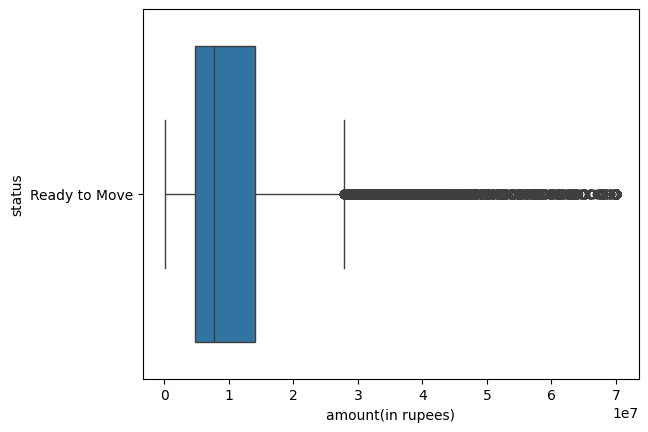

In [23]:
sns.boxplot(data=df, x=target, y='status')

In [24]:

print(df.columns)
df = df.drop(['status', 'index', 'title', 'price (in rupees)', 'description', 'overlooking', 'society', 'plot area', 'dimensions', 'ownership'], axis=1)

Index(['index', 'title', 'description', 'amount(in rupees)',
       'price (in rupees)', 'location', 'carpet area', 'status', 'floor',
       'transaction', 'furnishing', 'facing', 'overlooking', 'society',
       'bathroom', 'balcony', 'car parking', 'ownership', 'super area',
       'dimensions', 'plot area'],
      dtype='object')


In [25]:
print(df.columns)

Index(['amount(in rupees)', 'location', 'carpet area', 'floor', 'transaction',
       'furnishing', 'facing', 'bathroom', 'balcony', 'car parking',
       'super area'],
      dtype='object')


In [26]:

#sns.heatmap(df.select_dtypes(include='number').corr())

In [27]:
df['balcony'] = df['balcony'].replace('> 10', 11)
df['balcony'] = pd.to_numeric(df['balcony'], errors='coerce')
print(df['balcony'].isna().sum())
print(df['balcony'].unique())
# Заполним и переведем в инт на моменте пайплайна


47045
[ 2. nan  1.  3.  4.  6.  5. 10. 11.  7.  8.  9.]


In [28]:
df['car parking'].unique()
# Несколько гипотез, во первых наличие парковки повышает стоимость прямопропорционально количеству мест, поэтому имеет смысл в разделить номера парковачных мест, которые ничего не значат от статуса. По умолчанию считать что nan это отсутсвие парковки, и сделать 2 колонки это количество мест на парковке и крытая она или нет. Количество мест обычная целочисленная колонка, крытая или нет колнка covered с 1-крытая и 0-открытая

df['car parking'] = df['car parking'].str.lower().str.strip()
df['car covered'] = df['car parking'].str.contains('covered', na=False).astype(int)
df['parking count'] = df['car parking'].str.count(',') + 1
print(df['parking count'].isna().sum())
df['parking count'] = df['parking count'].fillna(0)
print(df.groupby(df['car covered'])[target].mean())

# Гипотеза подтвердилась


95735
car covered
0    8.458711e+06
1    1.539946e+07
Name: amount(in rupees), dtype: float64


Провел головадумать и вывел 2 новых признака. после проверки подтвердил прямую корреляцию между таргетом и количеством мест а также наличием крытой парковки.

In [29]:
#sns.histplot(df[df_original['Price (in rupees)'].isna()]['amount(in rupees)'])

In [30]:
print(df['amount(in rupees)'].isna().sum())
print(df[target].isna().sum())


0
0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 176665 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   amount(in rupees)  176665 non-null  float64
 1   location           176665 non-null  object 
 2   carpet area        100557 non-null  object 
 3   floor              169756 non-null  object 
 4   transaction        176598 non-null  object 
 5   furnishing         174607 non-null  object 
 6   facing             111046 non-null  object 
 7   bathroom           175906 non-null  float64
 8   balcony            129620 non-null  float64
 9   car parking        80930 non-null   object 
 10  super area         76018 non-null   object 
 11  car covered        176665 non-null  int64  
 12  parking count      176665 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 18.9+ MB


In [32]:
print(df['furnishing'].unique())

furnishing_map = {
    'Unfurnished': 0,
    'Semi-Furnished': 1,
    'Furnished': 2

}
df['furnishing'] = df['furnishing'].map(furnishing_map)

['Unfurnished' 'Semi-Furnished' 'Furnished' nan]


In [33]:


print(df.groupby('furnishing')[target].agg(['mean', 'median', 'count']))

#Получается что меблированная стоит дешевле чем полу меблированная. Звучит как бред, хотя на самом деле есть идея, что меблированная дешевле, потому что квартиры полностью с мебелью уже были жилыми, то есть resale в параметре Transaction. А это может влиять на цену, то есть полу меблированная стоит дороже, а полностью меблированная хоть и получает в стоимости, но эта разница покрывается в минус за счет того что большинство мебелированных это resale.

print('\n', pd.crosstab(df['furnishing'], df['transaction'], normalize='index'))

print('\n', df.groupby('transaction')[target].mean())

print(df['transaction'].value_counts())

df = df[df['transaction'].isin(['New Property', 'Resale'])]


                    mean     median  count
furnishing                                
0.0         1.009350e+07  7000000.0  72712
1.0         1.238455e+07  8640000.0  82543
2.0         1.060618e+07  7300000.0  19352

 transaction  New Property     Other  Rent/Lease    Resale
furnishing                                               
0.0              0.273677  0.000138    0.000000  0.726186
1.0              0.225940  0.000339    0.000024  0.773696
2.0              0.108227  0.034386    0.000000  0.857387

 transaction
New Property    1.325451e+07
Other           4.785818e+06
Rent/Lease      5.250000e+06
Resale          1.061094e+07
Name: amount(in rupees), dtype: float64
transaction
Resale          135262
New Property     40631
Other              703
Rent/Lease           2
Name: count, dtype: int64


In [34]:
df['transaction'] = np.where(df['transaction'] == 'New Property', 1, 0)

In [35]:
from sklearn.model_selection import KFold

In [36]:
def target_encoding_cv(train, test, col, n_splits=5, smoothing=10):

  kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
  train_encoded = pd.Series(index=train.index, dtype = float)

  for train.idx, val.idx in kf.split(train):
    means = train.iloc[train_idx].groupby(col)[target].agg[['mean', 'count']]

    means['encoded'] = (
        (means['count'] * means['mean'] + smoothing - prior)/ (means['count'] + smoothing)

    )
    train_encoded.iloc[val_idx] = (
            train.iloc[val_idx][col].map(means['encoded']).fillna(prior)
        )

  means_full = train.groupby(col)[target].agg(['mean', 'count'])
  means_full['encoded'] = (
      (means_full['count'] * means_full['mean'] + smoothing * prior) /
      (means_full['count'] + smoothing)
  )
  test_encoded = test[col].map(means_full['encoded']).fillna(prior)

  return train_encoded, test_encoded

In [37]:
print(df['super area'].isna().sum())

print(df['carpet area'].isna().sum())


df['super_area_missing'] = df['super area'].isna()
df['carpet_area_missing'] = df['carpet area'].isna()
print(df.groupby('super_area_missing')['carpet_area_missing'].agg(['mean', 'count']))


99882
76101
                        mean  count
super_area_missing                 
False               1.000000  76011
True                0.000901  99882


In [38]:
import re

def parse_area(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()


    match = re.search(r'([\d.]+)\s*([a-z]+)', x)
    if not match:

        try:
            return float(x)
        except ValueError:
            return np.nan

    value = float(match.group(1))
    unit = match.group(2)


    if unit in ['sqft', 'sq.ft', 'sq-ft']:
        return value
    elif unit == 'sqm':
        return value * 10.7639
    elif unit == 'acre':
        return value * 43560
    elif unit == 'sqyrd':
        return value * 9
    elif unit == 'sqin':
        return value / 144
    else:
        return value

In [39]:
df['super_area_sqft'] = df['super area'].apply(parse_area)

In [40]:
df['carpet_area_sqft'] = df['carpet area'].apply(parse_area)

In [41]:
print(df['super area'].isna().sum())
print(df['carpet area'].isna().sum())

print(df[df['super_area_missing'] == 0].groupby('super_area_sqft')['amount(in rupees)'].agg(['mean', 'count']))

print(df[df['carpet_area_missing'] == 0].groupby('carpet_area_sqft')['amount(in rupees)'].agg(['mean', 'count']))

99882
76101
                       mean  count
super_area_sqft                   
0.00             11250000.0      2
1.00              4500000.0      1
2.00             12000000.0      1
4.00             10000000.0      1
5.00              6495000.0      2
...                     ...    ...
8611.12           3900000.0      1
9450.00          51900000.0      1
10890.00          4000000.0      1
13993.07          5500000.0      1
43472880.00       2700000.0      1

[2657 rows x 2 columns]
                        mean  count
carpet_area_sqft                   
1.0               17900000.0      5
2.0                6800000.0      1
3.0               13500000.0      1
5.0                 220000.0      1
12.0               3500000.0      1
...                      ...    ...
194936.0          26000000.0      1
282004.0           2000000.0      1
495970.0           1900000.0      1
709222.0           6000000.0      1
65340000.0         5500000.0      1

[2473 rows x 2 columns]


In [42]:

print(df['carpet_area_sqft'].isna().sum())

76101


In [43]:
print(df.head(10))

   amount(in rupees) location carpet area            floor  transaction  \
0          4200000.0    thane    500 sqft     10 out of 11            0   
1          9800000.0    thane    473 sqft      3 out of 22            0   
2         14000000.0    thane    779 sqft     10 out of 29            0   
3          2500000.0    thane    530 sqft       1 out of 3            0   
4         16000000.0    thane    635 sqft     20 out of 42            0   
5          4500000.0    thane         NaN       2 out of 7            0   
6          1650000.0    thane    550 sqft       4 out of 5            0   
7          6000000.0    thane         NaN  Ground out of 7            0   
8          6000000.0    thane         NaN  Ground out of 2            0   
9         16000000.0    thane    900 sqft      3 out of 27            0   

   furnishing facing  bathroom  balcony car parking super area  car covered  \
0         0.0    NaN       1.0      2.0         NaN        NaN            0   
1         1.0   

In [44]:
df = df[
    (df['carpet_area_sqft'].between(100, 20000)) |
    (df['carpet_area_sqft'].isna())
]
df = df[
    (df['super_area_sqft'].between(100, 5000)) |
    (df['super_area_sqft'].isna())
]

In [45]:
print(df['facing'].unique())

[nan 'East' 'West' 'North - East' 'North' 'North - West' 'South'
 'South -West' 'South - East']


In [46]:
print(df.columns)

Index(['amount(in rupees)', 'location', 'carpet area', 'floor', 'transaction',
       'furnishing', 'facing', 'bathroom', 'balcony', 'car parking',
       'super area', 'car covered', 'parking count', 'super_area_missing',
       'carpet_area_missing', 'super_area_sqft', 'carpet_area_sqft'],
      dtype='object')


In [47]:
df = df.drop(['super area', 'carpet area', 'super_area_missing', 'carpet_area_missing'], axis=1)

In [48]:
df = df.drop('car parking', axis=1)

In [49]:
df['facing'] = df['facing'].fillna('missing')
df['facing'] = df['facing'].str.lower()


In [50]:
print(df['facing'].unique())


['missing' 'east' 'west' 'north - east' 'north' 'north - west' 'south'
 'south -west' 'south - east']


In [51]:
def parse_floor_current(x):
  if pd.isna(x):
    return np.nan

  x = str(x).strip().lower()

  if x.startswith('ground'):
    return 0

  match = re.search(r'^(\d+)', x)
  if match:
    return int(match.group(1))

  return np.nan

def parse_floor_total(x):
  if pd.isna(x):
    return np.nan

  x = str(x).strip().lower()

  match = re.search(r'out of\s*(\d+)', x)
  if match:
    return int(match.group(1))

  match = re.search(r'^(\d+)$', x)
  if match:
    return int(match.group(1))

  return np.nan


In [52]:
df['floor_current'] = df['floor'].apply(parse_floor_current)
df['floor_total'] = df['floor'].apply(parse_floor_total)


In [53]:
mask = df['floor'].notna() & df['floor_total'].isna()

df = df[~mask]


In [54]:
print(df[['floor', 'floor_current', 'floor_total']].head(5))

          floor  floor_current  floor_total
0  10 out of 11           10.0         11.0
1   3 out of 22            3.0         22.0
2  10 out of 29           10.0         29.0
3    1 out of 3            1.0          3.0
4  20 out of 42           20.0         42.0


In [55]:
df = df.drop('floor', axis=1)

In [56]:
print(df[target].head(5))

0     4200000.0
1     9800000.0
2    14000000.0
3     2500000.0
4    16000000.0
Name: amount(in rupees), dtype: float64


In [102]:
print(df.columns)

Index(['amount(in rupees)', 'location', 'transaction', 'furnishing', 'facing',
       'bathroom', 'balcony', 'car covered', 'parking count',
       'super_area_sqft', 'carpet_area_sqft', 'floor_current', 'floor_total'],
      dtype='object')


Гипотеза подтвердилась частично, мебелированная на 11% чаще resale, чем new. resale дешевле на 12% в сравнении с new, что значимо. Полу-мебелированая на 4.2% дороже чем мебелированная. В средних значениях имеем полу-мебелировная на 300 рупий дороже. А resale на 850 рупий дешевле. Разница в использовании 11% следовательно имее 11/100 * 850 = 90. Итого 300+90 имеем почти 400 рупий. То есть разница в цене resale не перебивает разницу в мебеллировании.
#

In [58]:
#sns.heatmap(df.select_dtypes(include='number').corr())

In [101]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import time
from sklearn.metrics import mean_absolute_percentage_error
import optuna
import lightgbm as lgb
import category_encoders as ce
from catboost import CatBoostRegressor

In [103]:
#BASELINE

X = df.drop(target, axis=1)
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nТаргет:")
print(y.describe())

X shape: (174819, 12)
y shape: (174819,)

Таргет:
count    1.748190e+05
mean     1.125161e+07
std      1.027777e+07
min      1.000000e+05
25%      5.000000e+06
50%      7.800000e+06
75%      1.440000e+07
max      7.000000e+07
Name: amount(in rupees), dtype: float64


In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [75]:
# encoder_facing = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

# facing_train = encoder_facing.fit_transform(X_train[['facing']])
# facing_test = encoder_facing.transform(X_test[['facing']])

# facing_cols = encoder_facing.get_feature_names_out(['facing'])
# facing_train_df = pd.DataFrame(facing_train, columns=facing_cols, index=X_train.index)
# facing_test_df = pd.DataFrame(facing_test, columns=facing_cols, index=X_test.index)

# X_train = X_train.drop(columns = 'facing')
# X_test = X_test.drop(columns = 'facing')

# X_train = pd.concat([X_train, facing_train_df], axis=1)
# X_test = pd.concat([X_test, facing_test_df], axis=1)

In [76]:
# encoder = ce.TargetEncoder(cols=['location'], smoothing=10)

# X_train = encoder.fit_transform(X_train, y_train)
# X_test = encoder.transform(X_test)





In [105]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [106]:
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorial_features = X_train.select_dtypes(include='object').columns.tolist()

In [66]:
#PIPELINE Random Forest Regressor
#numeric_transformer = Pipeline([
#    ('imputer', SimpleImputer(strategy='median')),
#    ('scaler', StandardScaler())
# ])

# categorial_transformer = Pipeline([
#     ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
#     ('onehotencode', OneHotEncoder(handle_unknown='ignore', drop='first', max_categories=20))
# ])
# preprocessor = ColumnTransformer([
#     ('num', numeric_transformer, numeric_features),
#     ('cat', categorial_transformer, categorial_features)
# ])
# model = RandomForestRegressor(n_estimators= 180, max_depth=25, min_samples_split=2, min_samples_leaf=1, max_features=0.7509776412241582, max_samples=0.9562634426883665, n_jobs=1, random_state=42)

# pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', model)
# ])

# pipeline.fit(X_train, y_train_log)





In [107]:


print(f"X_train shape: {X_train.shape}")
print(f"y_train_log shape: {y_train_log.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test_log shape: {y_test_log.shape}")

X_train shape: (139855, 12)
y_train_log shape: (139855,)
X_test shape: (34964, 12)
y_test_log shape: (34964,)


In [80]:
# # PIPELINE LGBM regressor
# numeric_transformer = Pipeline([
#    ('imputer', SimpleImputer(strategy='median')),
#    ('scaler', StandardScaler())
# ])

# categorial_transformer = Pipeline([
#     ('imputer', SimpleImputer(strategy='constant', fill_value='missing'))
# ])
# preprocessor = ColumnTransformer([
#     ('num', numeric_transformer, numeric_features),
#     ('cat', categorial_transformer, categorial_features)
# ])

# model = lgb.LGBMRegressor(n_estimators = 1971, learning_rate = 0.08855706462133571, num_leaves = 136,  max_depth = 10, min_child_samples = 46, subsample= 0.8372315466266708, colsample_bytree = 0.8333324377961918, reg_lambda = 0.27299801033544263)

# pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', model)
# ])

# pipeline.fit(
#     X_train, y_train_log
# )

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['location', 'transaction',
                                                   'furnishing', 'bathroom',
                                                   'balcony', 'car covered',
                                                   'parking count',
                                                   'super_area_sqft',
                                                   'carpet_area_sqft',
                                                   'floor_current',
                                                   'floor_total',
                                                   'facing_missing',
                                                   'facing_north',
                                                   '...
                                                   'facing_south -west',
                                                   'facing_west']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'))]),
                                                  [])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8333324377961918,
                               learning_rate=0.08855706462133571, max_depth=10,
                               min_child_samples=46, n_estimators=1971,
                               num_leaves=136, reg_lambda=0.27299801033544263,
                               subsample=0.8372315466266708))])

In [111]:
# PIPELINE cat GBM regressor

cat_features = ['location', 'facing']


X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

for col in cat_features:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

from sklearn.impute import SimpleImputer

numeric_cols = [col for col in X_train_cat.columns if col not in cat_features]
imputer = SimpleImputer(strategy='median')

X_train_cat[numeric_cols] = imputer.fit_transform(X_train_cat[numeric_cols])
X_test_cat[numeric_cols] = imputer.transform(X_test_cat[numeric_cols])





In [ ]:

# model_cat = CatBoostRegressor(
#     iterations=2000,
#     learning_rate=0.05,
#     depth=8,
#     cat_features=cat_features,
#     verbose=100,
#     random_seed=42,
#     early_stopping_rounds=100
# )
# model_cat.fit(
#     X_train_cat, y_train_log,
#     eval_set=(X_test_cat, y_test_log),
#     use_best_model=True
# )

In [110]:
y_pred_log_cat = model_cat.predict(X_test_cat)
y_pred_cat = np.expm1(y_pred_log_cat)

mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(((y_test - y_pred_cat) ** 2).mean())
r2_cat = r2_score(y_test, y_pred_cat)
mape_cat = mean_absolute_percentage_error(y_test, y_pred_cat)

print(f"\n{'=' * 60}")
print(f"{'CatBoost Regressor'}")
print(f"{'=' * 60}")
print(f"MAE:  {mae_cat:,.0f} рупий")
print(f"RMSE: {rmse_cat:,.0f} рупий")
print(f"R²:   {r2_cat:.4f}")
print(f"MAPE: {mape_cat * 100:.2f}%")


CatBoost Regressor
MAE:  928,719 рупий
RMSE: 2,591,000 рупий
R²:   0.9380
MAPE: 10.29%


In [109]:
y_pred_log = pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(((y_test - y_pred) ** 2).mean())
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"\n{'=' * 60}")
print(f"{'LGBM Regressor'}")
print(f"{'=' * 60}")
print(f"MAE:  {mae:,.0f} рупий")
print(f"RMSE: {rmse:,.0f} рупий")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape * 100:.2f}%")

ValueError: columns are missing: {'facing_south -west', 'facing_north - west', 'facing_missing', 'facing_west', 'facing_north - east', 'facing_south - east', 'facing_north', 'facing_south'}

In [70]:
def objective(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 300),
      'max_depth': trial.suggest_int('max_depth', 5, 30),
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
      'max_features': trial.suggest_float('max_features', 0.3, 1.0),
      'max_samples': trial.suggest_float('max_samples', 0.5, 1.0)
  }

  model = RandomForestRegressor(**params, n_jobs=1, random_state=42)
  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('model', model)
  ])

  pipeline.fit(X_train, y_train_log)

  y_pred_log = pipeline.predict(X_test)
  y_pred = np.expm1(y_pred_log)

  mape = mean_absolute_percentage_error(y_test, y_pred)
  return mape



In [71]:
def objective_lgb(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 1000, 3000),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
      'num_leaves': trial.suggest_int('num_leaves', 31, 256),
      'max_depth': trial.suggest_int('max_depth', 6, 12),
      'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
      'subsample': trial.suggest_float('subsample', 0.6, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 10, log=True)
  }

  model = lgb.LGBMRegressor(**params, n_jobs=1, random_state=42, verbose=-1)
  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('model', model)
  ])

  pipeline.fit(X_train, y_train_log)

  y_pred_log = pipeline.predict(X_test)
  y_pred = np.expm1(y_pred_log)

  mape = mean_absolute_percentage_error(y_test, y_pred)
  return mape


In [ ]:
def objective_cgb(trial):
  params = {
      'iterations': trial.suggest_int('n_estimators', 1000, 3000),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
      'depth': trial.suggest_int('max_depth', 6, 16),
      cat_features=cat_features
      'subsample': trial.suggest_float('subsample', 0.6, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 10, log=True)
  }

  model = lgb.LGBMRegressor(**params, n_jobs=1, random_state=42, verbose=-1)
  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('model', model)
  ])

  pipeline.fit(X_train, y_train_log)

  y_pred_log = pipeline.predict(X_test)
  y_pred = np.expm1(y_pred_log)

  mape = mean_absolute_percentage_error(y_test, y_pred)
  return mape

  # model_cat = CatBoostRegressor(
#     iterations=2000,
#     learning_rate=0.05,
#     depth=8,
#     cat_features=cat_features,
#     verbose=100,
#     random_seed=42,
#     early_stopping_rounds=100
# )

In [ ]:

#study = optuna.create_study(direction='minimize')

#study.optimize(objective, n_trials=50, show_progress_bar=False)

#print(f"Best MAPE: {study.best_value * 100:.2f}%")
#print(f"Best params: {study.best_params}")

In [72]:
# study = optuna.create_study(direction='minimize')

# study.optimize(objective_lgb, n_trials=20, show_progress_bar=False)

# print(f"Best MAPE: {study.best_value * 100:.2f}%")
# print(f"Best params: {study.best_params}")

[I 2026-09-17 03:30:42,907] A new study created in memory with name: no-name-b7e3609c-27f4-45d6-8701-621dcf702174
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-09-17 03:31:44,275] Trial 0 finished with value: 0.09480496988907611 and parameters: {'n_estimators': 1824, 'learning_rate': 0.026330991532250554, 'num_leaves': 247, 'max_depth': 12, 'min_child_samples': 29, 'subsample': 0.9028739810674659, 'colsample_bytree': 0.9983688430341886, 'reg_lambda': 0.5206798213821849}. Best is trial 0 with value: 0.09480496988907611.
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-09-17 03:32:16,054] Trial 1 finished with value: 0.09460323760428886 and parameters: {'n_estimators': 1660, 'learning_rate': 0.

Best MAPE: 9.36%
Best params: {'n_estimators': 1971, 'learning_rate': 0.08855706462133571, 'num_leaves': 136, 'max_depth': 10, 'min_child_samples': 46, 'subsample': 0.8372315466266708, 'colsample_bytree': 0.8333324377961918, 'reg_lambda': 0.27299801033544263}
